#  Gravitational Wave Data Analysis tutorial #2

This notebook gives an introductions to Bayesian inference and parameter inference for gravitational wave signals from compact binary coalescences (CBCs), with an application to recover the (simplified) parameters of GW150914 in real data.

We refer to the lectures and tutorials available at the GWOSC: [Gravitational-Wave Open Science Center (GWOSC)](https://www.gw-openscience.org).

Another useful workshop dealing with the simulation and analysis of LISA data is available here: [LISA Data Generation and Analysis Workshop](https://indico.in2p3.fr/event/33255/overview)
    
[Click this link to view this tutorial in Google Colaboratory](https://colab.research.google.com/github/SylvainMarsat/gwda_tutorial/blob/main/tutorial_2.ipynb)

Author date

When running in Google Colab, uncomment and run the cell to install latex for matplotlib:

## Install

When running in Google Colab, uncomment and run the cell to install required packages:

In [ ]:
#! pip install numpy scipy h5py matplotlib ipython jupyterlab tqdm lalsuite gwpy eryn corner bilby

When running in Google Colab, uncomment and run the cell to download the required data:

## Imports

In [1]:
import os, sys
import h5py, json
import copy
import numpy as np
import scipy
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt

from tqdm.notebook import tqdm as tqdm

import astropy.units as u

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio") # to silence a warning
import lal
import lalsimulation
import lalsimulation.gwsignal.core.waveform as wfm
from lalsimulation.gwsignal import gwsignal_get_waveform_generator

import gwpy

# import ptemcee
import eryn
import corner
import bilby

The pyseobnr package has failed to load, you will not be able to employ SEOBNRv5 approximants.


In [2]:
%matplotlib inline

## Definitions

In [3]:
colors = ["#4C72B0", "#C44E52", "#CCB974", "#55A868", "#8172B2", "#64B5CD", '#FFA500', '#A0522D']

rc_params = {'backend': 'ps',
            'axes.unicode_minus':False,
            'axes.grid':True,
            'lines.linewidth':1.,
            'grid.linestyle':':',
            'grid.linewidth':1.,
            'hist.bins':50,
            'axes.labelsize':16,
            'axes.titlesize':16,
            'xtick.labelsize':16,
            'ytick.labelsize':16,
            'legend.fontsize':16,
            'figure.dpi':100}
plt.rcParams.update(rc_params)

In [4]:
# Definitions for the windowing function -- function for vectorial argument
# In order to avoid overflows in the exponentials, we set the boundaries (di, df) so that anything below 10^-20 is considered zero
def window_planck(x, xi, xf, deltaxi, deltaxf):
    di = deltaxi/(20*np.log(10))
    df = deltaxf/(20*np.log(10))
    w = np.zeros(len(x), dtype=float)
    #
    mask = (x <= xi + di) | (x >= xf - df)
    w[mask] = 0.
    #
    mask = (xi + di < x) & (x < xi + deltaxi - di)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(deltaxi/(xm - xi) + deltaxi/(xm - (xi + deltaxi))))
    #
    mask = (xi + deltaxi - di <= x) & (x <= xf - deltaxf + df)
    w[mask] = 1.
    #
    mask = (xf - deltaxf + df < x) & (x < xf - df)
    xm = x[mask]
    w[mask] = 1./(1 + np.exp(-(deltaxf/(xm - (xf - deltaxf))) - deltaxf/(xm - xf)))
    #
    return w

In [5]:
def fft_positivef(times, data):
    n = len(times)
    deltat = times[1] - times[0]
    deltaf = 1./(n*deltat)
    # Fast Fourier Transform
    freqs = deltaf*np.arange(n)
    # BEWARE: due to the different convention for the sign of Fourier frequencies, we have to reverse the FFT output
    # Beware also that the FFT treats effectively the initial time as 0
    # BEWARE: in the reversion of the numpy-convention FFT output, we have to set aside the 0-frequency term
    data_fd = deltat * np.fft.fft(data)
    # Discarding information on negative frequencies - if real timeseries in input, no information loss as the deleted values are the conjugate
    data_fd = data_fd[:n//2+1]
    freqs = freqs[:n//2+1]
    # Coming back to the initial times
    tshift = times[0]
    fac_timeshift = np.exp(1j*2*np.pi*freqs*tshift)
    data_fd = data_fd * fac_timeshift
    return freqs, data_fd

In [6]:
def ifft_positivef(freqs, data, tstart=0., real=False):
    # Assumes n = N/2+1, with N length of data
    n = len(freqs)
    deltaf = freqs[1] - freqs[0]
    # Zero-pad to next power of 2, then 0-pad by factor 2 for the negative frequencies
    N = 2*(n - 1)
    # N_pad = 2**(int(np.ceil(np.log(N) / np.log(2))) + 1)
    freqs_pad = deltaf * np.arange(N)
    data_pad = np.zeros(N, dtype=data.dtype)
    data_pad[:n] = data
    # If data is FFT of real data, complete implicit f<0 values in the second half of the vector
    if real:
        data_pad[n:] = np.conj(data[1:n-1][::-1])
    # Factor to restore times
    fac_timeshift = np.exp(-1j*2*np.pi*freqs_pad*tstart)
    # Inverse FFT
    deltat = 1./(N*deltaf)
    data_td = 1./deltat * np.fft.ifft(fac_timeshift * data_pad)
    if real:
        data_td = np.real(data_td)
    # Rebuild times
    times = tstart + deltat * np.arange(N)
    return times, data_td

## Strain data

In [7]:
from gwosc import datasets
from gwosc.datasets import find_datasets
from gwosc.datasets import event_gps

from gwpy.timeseries import TimeSeries

In [8]:
t_gps = event_gps('GW150914')
print(t_gps)

1126259462.4


In [9]:
H1_data = TimeSeries.read('./data/GW150914/H-H1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")
L1_data = TimeSeries.read('./data/GW150914/L-L1_GWOSC_4KHZ_R1-1126259447-32.hdf5', format="hdf5.gwosc")

In [599]:
# segment = (int(t_gps) - 16, int(t_gps) + 16)
# H1_data = TimeSeries.fetch_open_data('H1', *segment, verbose=True, cache=True)
# L1_data = TimeSeries.fetch_open_data('L1', *segment, verbose=True, cache=True)

Fetched 1 URLs from gwosc.org for [1187008877 .. 1187008887))
Reading data... [Done]
Fetched 1 URLs from gwosc.org for [1187008877 .. 1187008887))
Reading data... [Done]


In [32]:
times = np.asarray(H1_data.times).copy()
# New origin of times: middle of our data interval
t_center = times[len(times)//2]
times -= t_center
tevent = t_gps - t_center
strain_H1 = np.asarray(H1_data).copy()
strain_L1 = np.asarray(L1_data).copy() + 1e-18 # Strain is shifted by a constant, unknown why

dt = H1_data.dt.value
fs = 1./dt
dt, fs, len(times)

(np.float64(0.000244140625), np.float64(4096.0), 131072)

## Evaluate PSD

In [33]:
freqs_psd, psd_H1 = scipy.signal.welch(strain_H1, fs,  window='hann', nperseg=16384, scaling='density')
freqs_psd, psd_L1 = scipy.signal.welch(strain_L1, fs,  window='hann', nperseg=16384, scaling='density')

# We will use interpolations of the ASDs computed above for whitening:
psd_H1_interp = scipy.interpolate.interp1d(freqs_psd, psd_H1)
psd_L1_interp = scipy.interpolate.interp1d(freqs_psd, psd_L1)

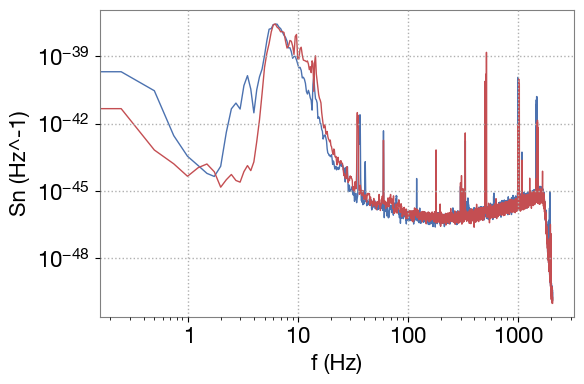

In [12]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(freqs_psd, psd_H1, c=colors[0], lw=1)
ax.loglog(freqs_psd, psd_L1, c=colors[1], lw=1)

# ax.set_xlim([5., 2048.])
ax.set_xlabel(r'f (Hz)')
ax.set_ylabel(r'Sn (Hz^-1)')

fig.tight_layout()

## Signal model: A exp(i alpha) * h22(f)

In [41]:
def PhenomXAS_LAL(freqs, M, q, chi1z, chi2z, dist, f_ref=100., phi_ref=0., Deltat=0.):
    
    Ms = M * lal.MTSUN_SI
    
    m1_SI = M * q/(1.+q) * lal.MSUN_SI
    m2_SI = M * 1./(1.+q) * lal.MSUN_SI
    
    dist_SI = (dist * 1e6 * lal.PC_SI)
    
    lal_params = lal.CreateDict()
    # NOTE: we set this to deactivate multibanding
    # lalsim.SimInspiralWaveformParamsInsertPhenomXHMThresholdMband(lal_params, 0)
    
    # Amplitude prefactor for physical units
#     amp0 = M * lal.MRSUN_SI * M * lal.MTSUN_SI / (dist * 1e6 * lal.PC_SI);

    # Input frequency sequence
    freqsSequence = lal.CreateREAL8Sequence(len(freqs))
    freqsSequence.data[:] = freqs[:]
    
    # Generate
    h22 = lalsimulation.SimIMRPhenomXASFrequencySequence(
        freqsSequence,
        m1_SI,
        m2_SI,
        chi1z,
        chi2z,
        dist_SI,
        phi_ref,
        f_ref,
        lal_params);

    # Extract data
    h2m2data = np.copy(h22.data.data)
    # NOTE: PhenomX FrequencySeries output is for frequencies ]-N/2, N/2] 
    # freq = deltaf * np.arange(-len(h22data)//2 + 1, len(h22data)//2 + 1)
    
    # Convention correction: no conjugation here, LAL convention (factor (-1)^l = 1 here anyway)
    # h22data = np.conj(h22data)
    
    # Add time shift by Deltat
    h2m2data *= np.exp(-2*1j*np.pi*Deltat*freqs)
        
    return freqs, h2m2data

In [61]:
def signal_h(freq, M, q, A, Deltat, alpha):
    m1 = M * q / (1+q)
    m2 = M * 1. / (1+q)
    dist = 1e3
    chi1 = 0.
    chi2 = 0.
    f, h2m2 = PhenomXAS_LAL(freq, M, q, chi1, chi2, dist, Deltat=Deltat)
    h2m2 *= A * np.exp(1j*alpha)
    return f, h2m2

In [83]:
list_params = ['M', 'q', 'A', 'Deltat', 'alpha']

def signal_dh(param, step, freq, M, q, A, Deltat, alpha):
    params = np.array([M, q, A, Deltat, alpha])
    params_plus = params.copy()
    params_minus = params.copy()
    i_param = list_params.index(param)
    params_plus[i_param] += step
    params_minus[i_param] -= step
    f, h2m2_plus = signal_h(freq, *params_plus)
    f, h2m2_minus = signal_h(freq, *params_minus)
    return f, (h2m2_plus - h2m2_minus) / (2*step)

def fisher(freq, M, q, A, Deltat, alpha, steps, list_params=list_params, return_cov=True):
    n_params = len(list_params)
    dh = {}
    for param in list_params:
        _, dh[param] = signal_dh(param, steps[param], freq, M, q, A, Deltat, alpha)
    fisher_matrix = np.empty((n_params, n_params), dtype=float)
    for i in range(n_params):
        for j in range(n_params):
            integrand = np.real(dh[list_params[i]] * np.conj(dh[list_params[j]])) * invpsd_vals
            fisher_matrix[i,j] = 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)
    fisher_cov = None
    if return_cov:
        fisher_cov = np.linalg.inv(fisher_matrix)
    return fisher_matrix, fisher_cov

In [45]:
dict_params

{'M': 0, 'q': 1, 'A': 2, 'Deltat': 3, 'alpha': 4}

In [52]:
Mmax, qmax, Amax, Deltatmax, alphamax = xmax
xmax

array([72.67701483,  1.02898998,  0.37424392, -0.57658854,
       -0.76416395])

In [86]:
steps = {'M':1e-5, 'q':1e-5, 'A':1e-5, 'Deltat':1e-7, 'alpha':1e-5}
fisher_test, cov_test = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, steps, list_params=list_params, return_cov=True)

In [88]:
np.sqrt(np.diag(cov_test))

array([1.22267473e+00, 3.89957424e+00, 2.57256116e-02,
       4.09407437e-04, 2.88679073e-01])

In [75]:
steps_base = {'M':1e-5, 'q':1e-5, 'A':1e-5, 'Deltat':1e-7, 'alpha':1e-5}
fisher_vals = {}

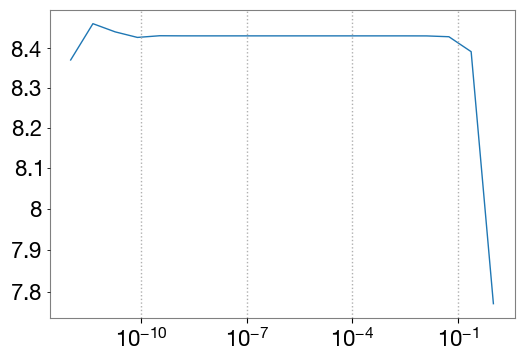

In [76]:
param = 'M'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])

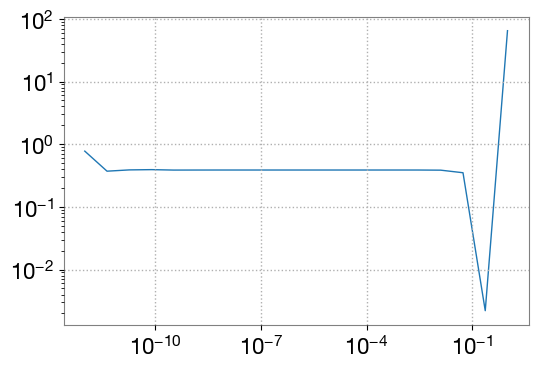

In [77]:
param = 'q'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])

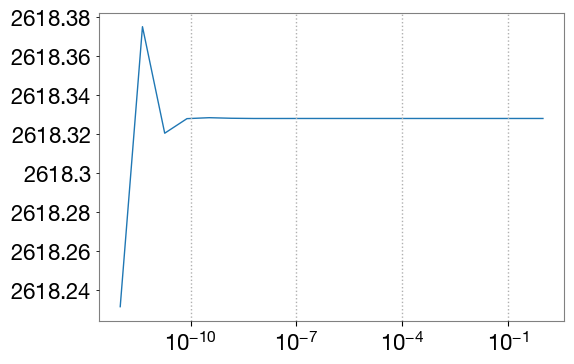

In [78]:
param = 'A'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])

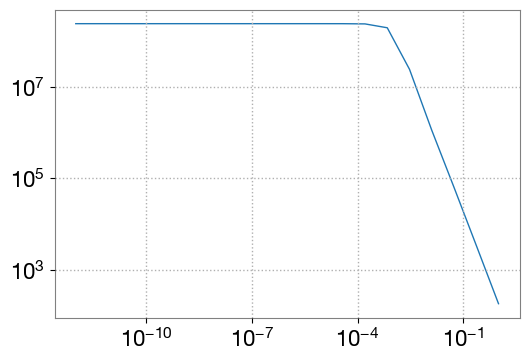

In [79]:
param = 'Deltat'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])

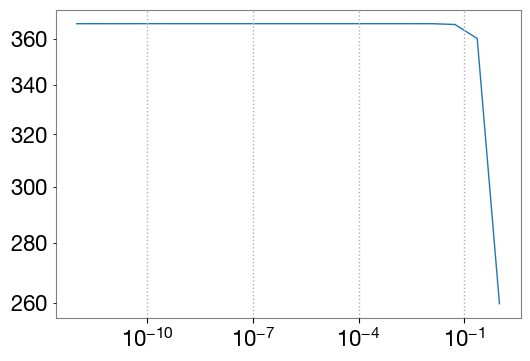

In [80]:
param = 'alpha'
npt = 20
steps_test = np.geomspace(1e-12, 1., npt)
fisher_vals[param] = np.zeros(npt, dtype=float)
for i in range(npt):
    fisher_step, _ = fisher(freq, Mmax, qmax, Amax, Deltatmax, alphamax, {param:steps_test[i]}, list_params=[param], return_cov=False)
    fisher_vals[param][i] = fisher_step[0,0]

fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(steps_test, fisher_vals[param])

## Setting up data, prior and likelihood

In [35]:
# Data selected to be +-4s around the event
# _d for 'data' that we are going to actually use

n = 2**np.round(np.log2(8. / dt))
mask_d = ( -n//2*dt <= times) & (times < n//2*dt)
times_d = times[mask_d]
strain_H1_d = strain_H1[mask_d]
strain_L1_d = strain_L1[mask_d]

n, n*dt, len(times_d), [times_d[0], times_d[-1]]

(np.float64(32768.0),
 np.float64(8.0),
 32768,
 [np.float64(-4.0), np.float64(3.999755859375)])

In [36]:
# Tapering data at both ends
w = window_planck(times_d, times_d[0], times_d[-1], 0.5, 0.5)
strain_H1_tap = w * strain_H1_d
strain_L1_tap = w * strain_L1_d

In [37]:
# Data FD
freq_H1, strain_H1_fd = fft_positivef(times_d, strain_H1_tap)
freq_L1, strain_L1_fd = fft_positivef(times_d, strain_L1_tap)

df = freq_H1[1] - freq_H1[0]
df

np.float64(0.125)

In [38]:
# Frequency range for inner products
mask = (10. < freq_H1) & (freq_H1 < 1024.)
freq = freq_H1[mask]
freq.shape

(8111,)

In [39]:
freq

array([  10.125,   10.25 ,   10.375, ..., 1023.625, 1023.75 ,
       1023.875], shape=(8111,))

In [43]:
f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

In [24]:
%timeit f, h = signal_h(freq, 60., 1.5, 1., 0., np.pi/3)

2.54 ms ± 93.8 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


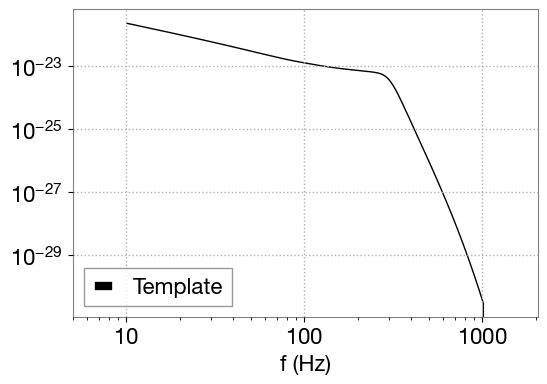

In [25]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.loglog(f, np.abs(h), c='k', label=r'Template')

ax.set_xlim(5., 2048.)

ax.set_xlabel(r'f (Hz)')
ax.legend(loc='lower left')

In [56]:
psd_vals = psd_H1_interp(freq)
invpsd_vals = 1./psd_vals

data = strain_H1_fd[mask]

In [27]:
def prior_check(x, prior_bounds):
    if prior_bounds is None:
        return True
    else:
        # NOTE: the following (faster) raises 'list indices must be integers or slices, not tuple'
        # but seems to depend on the version of python/numpy ?
        # return np.all((prior_bounds[:,0] <= x) * (x <= prior_bounds[:,1]))
        return np.all([(prior_bounds[i][0]<=x[i] and x[i]<=prior_bounds[i][1]) for i in range(len(x))])

def lnprior(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        return 0.

In [28]:
def lnlike(x, prior_bounds=None):
    if not prior_check(x, prior_bounds):
        return -1e99
    else:
        M, q, A, Deltat, alpha = x
        _, h_vals = signal_h(freq, M, q, A, Deltat, alpha)
        # h_vals = h['amp'] * np.exp(1j * h['phase'])
        resid = h_vals - data
        integrand = np.real(resid * np.conj(resid)) * invpsd_vals
        return -1./2 * 4*df* np.sum((integrand[1:] + integrand[:-1]) / 2)

## Sampling with Eryn

In [13]:
from eryn.ensemble import EnsembleSampler
from eryn.state import State
from eryn.prior import ProbDistContainer, uniform_dist
from eryn.utils import TransformContainer
from eryn.moves import GaussianMove, StretchMove, CombineMove
from eryn.utils.utility import groups_from_inds

In [144]:
# Params: M, q, A, Deltat, alpha
prior_range = np.array([
    [65., 75.],
    [1., 2.],
    [0., 2.],
    [-1., 1.],
    [-np.pi, np.pi]])

In [156]:
# set prior limits
ndim = 5
priors_in = {i: uniform_dist(prior_range[i][0], prior_range[i][1]) for i in range(ndim)}
priors = ProbDistContainer(priors_in)

In [157]:
ndim = 5
nwalkers = 32
ntemps = 5
Tmax = 50
nsteps = 1000
burn = int(nsteps/2)

# fill kwargs dictionary
tempering_kwargs=dict(ntemps=ntemps, Tmax=Tmax)

# Starting positions
# randomize throughout prior
coords = priors.rvs(size=(ntemps, nwalkers,))

# initialize sampler
ensemble = EnsembleSampler(
    nwalkers,
    ndim,
    lnlike,
    priors,
    args=[],
    kwargs={'prior_bounds': prior_range},
    tempering_kwargs=tempering_kwargs
)

In [158]:
out = ensemble.run_mcmc(coords, nsteps, burn=0, progress=True, thin_by=1)

100%|█████████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:37<00:00,  3.60it/s]


In [159]:
samples = ensemble.get_chain()['model_0']
log_likelihoods = ensemble.get_log_like()
samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

In [166]:
# Output to file
np.save('./samples/gw150914_example_eryn_samples.npy', samples)
np.save('./samples/gw150914_example_eryn_log_likelihoods.npy', log_likelihoods)

### Results

In [16]:
samples = np.load('./samples/gw150914_example_eryn_samples.npy')
log_likelihoods = np.load('./samples/gw150914_example_eryn_log_likelihoods.npy')

In [25]:
# Formats:
# samples: (nsteps, ntemps, nwalkers, nleaves_max, ndim).
# log_likelihoods: (nsteps, ntemps, nwalkers).

nsteps, ntemps, nwalkers, nleaves_max, ndim = samples.shape
burn = nsteps//2

samples.shape, log_likelihoods.shape

((1000, 5, 32, 1, 5), (1000, 5, 32))

In [26]:
temp = 0

samples_flat = np.zeros(((nsteps - burn) * nwalkers, ndim), dtype=float)
for i in range(ndim):
    samples_flat[:,i] = np.ravel(samples[burn:,temp,:,0,i], order='F')
lnlike_flat = np.ravel(log_likelihoods[burn:,temp,:], order='F')

In [27]:
samples_flat.shape, lnlike_flat.shape

((16000, 5), (16000,))

In [30]:
lnL_max = np.max(lnlike_flat)
imax = np.argmax(lnlike_flat)
xmax = samples_flat[imax, :]
xmax, lnL_max

(array([72.67701483,  1.02898998,  0.37424392, -0.57658854,
        -0.76416395]),
 np.float64(-13705.09576231493))

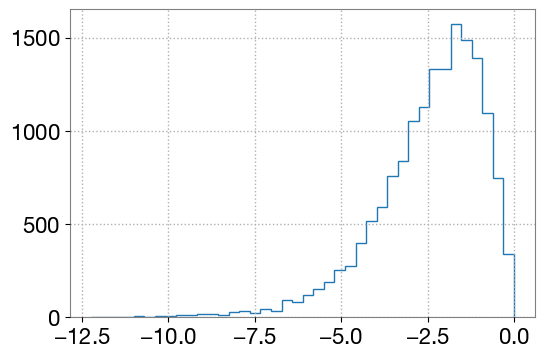

In [29]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_flat - lnL_max, histtype='step', bins=40);

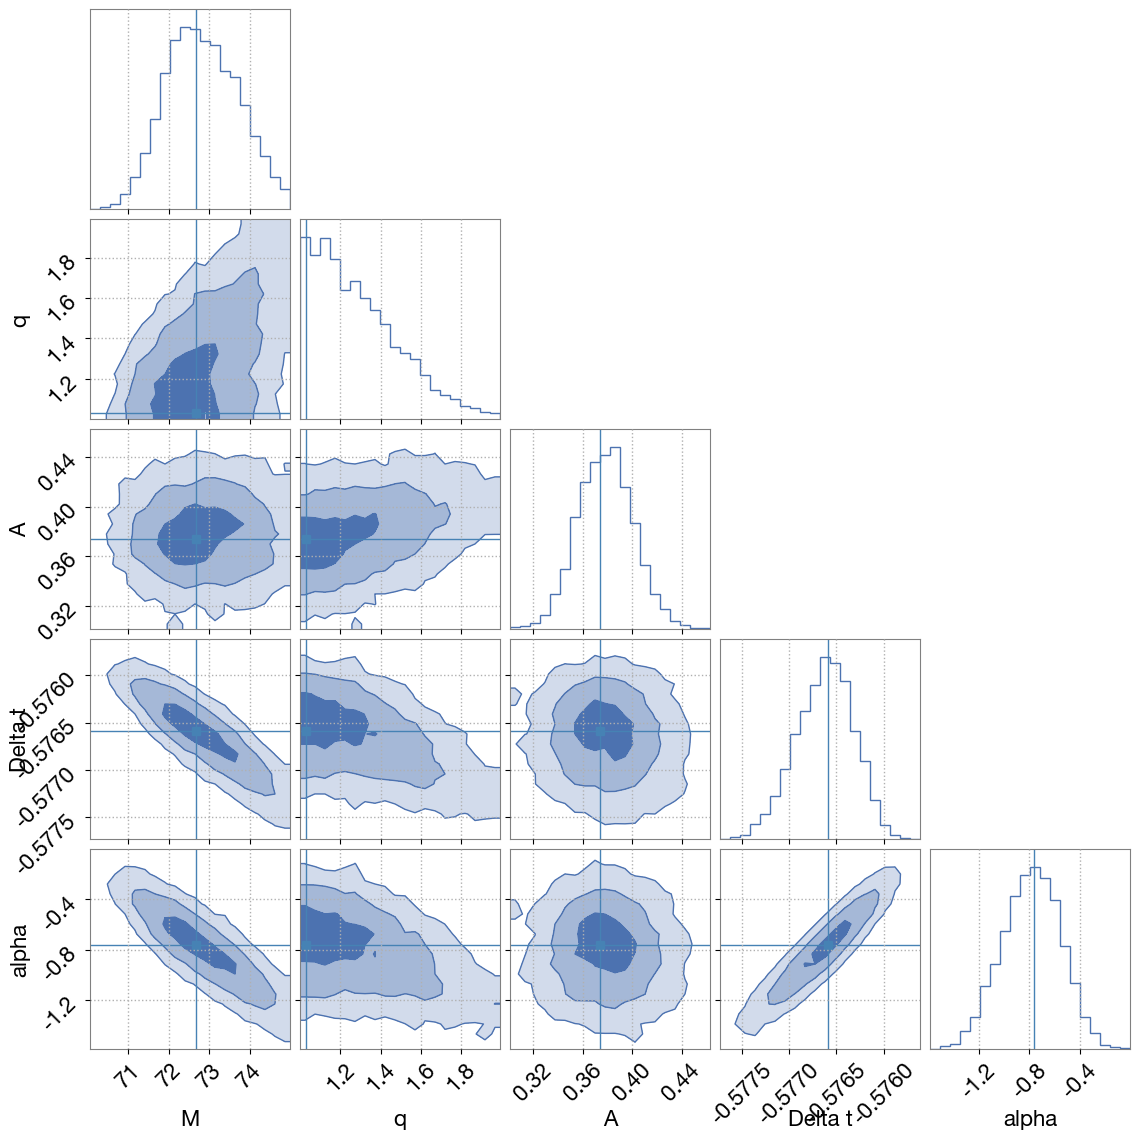

In [234]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(samples_flat, plot_density=False, plot_datapoints=False, levels=levels, truths=xmax, smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

In [88]:
np.sqrt(np.diag(cov_test))

array([1.22267473e+00, 3.89957424e+00, 2.57256116e-02,
       4.09407437e-04, 2.88679073e-01])

In [91]:
samples_fishercov = np.random.multivariate_normal(xmax, cov_test, size=100000)
samples_fishercov = samples_fishercov[samples_fishercov[:,1] > 1.]
samples_fishercov.shape

(50357, 5)

In [95]:
corner.corner?

Signature:
corner.corner(
    data,
    bins=20,
    *,
    range=None,
    axes_scale='linear',
    weights=None,
    color=None,
    hist_bin_factor=1,
    smooth=None,
    smooth1d=None,
    labels=None,
    label_kwargs=None,
    titles=None,
    show_titles=False,
    title_quantiles=None,
    title_fmt='.2f',
    title_kwargs=None,
    truths=None,
    truth_color='#4682b4',
    scale_hist=False,
    quantiles=None,
    verbose=False,
    fig=None,
    max_n_ticks=5,
    top_ticks=False,
    use_math_text=False,
    reverse=False,
    labelpad=0.0,
    hist_kwargs=None,
    group='posterior',
    var_names=None,
    filter_vars=None,
    coords=None,
    divergences=False,
    divergences_kwargs=None,
    labeller=None,
    **hist2d_kwargs,
)
Docstring:
Make a *sick* corner plot showing the projections of a data set in a
multi-dimensional space. kwargs are passed to hist2d() or used for
`matplotlib` styling.

Parameters
----------
data : obj
    Any object that can be converted t

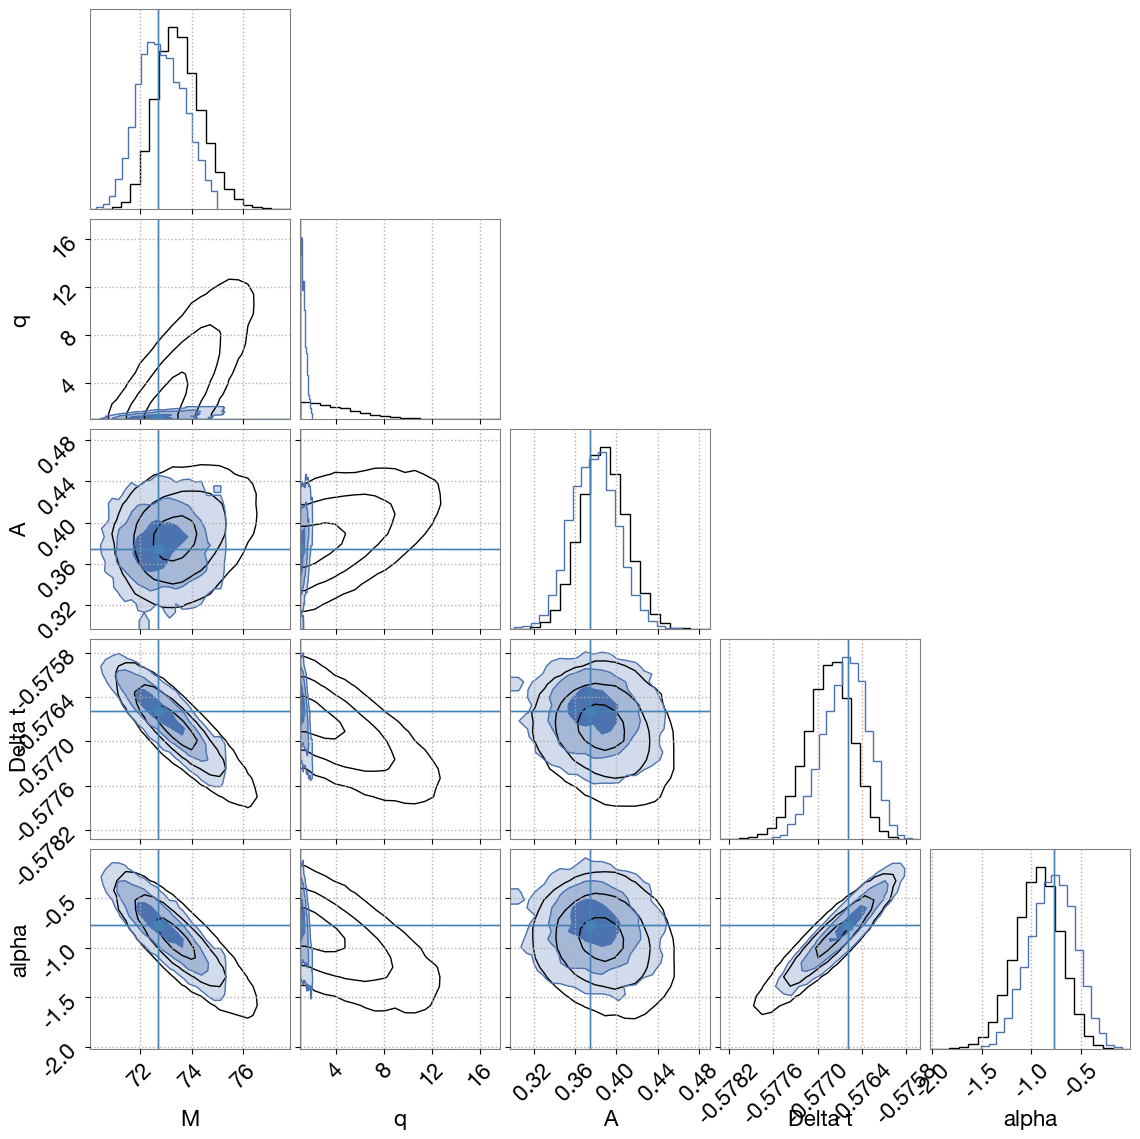

In [99]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

fig = corner.corner(samples_fishercov, plot_density=False, plot_datapoints=False, levels=levels, truths=xmax, smooth=0.5, color='k', fill_contours=False, labels=labels ,hist_kwargs={'density':True});
corner.corner(samples_flat, fig=fig, plot_density=False, plot_datapoints=False, levels=levels, truths=xmax, smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels, hist_kwargs={'density':True});

In [167]:
log_likelihoods.shape

(1000, 5, 32)

In [169]:
lnL_T0.shape

(1000, 32)

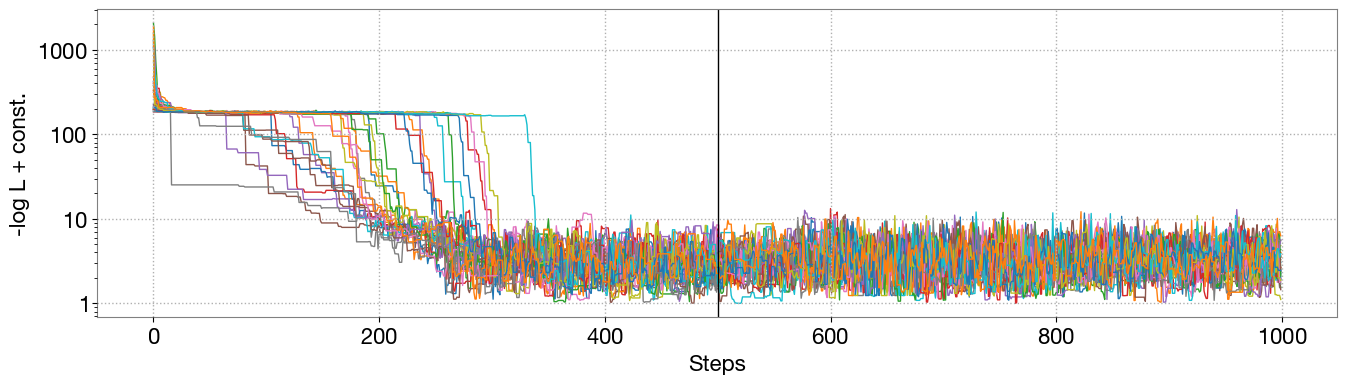

In [171]:
lnL_T0 = log_likelihoods[:,0,:]
lnL_max = np.max(lnL_T0)

fig, ax = plt.subplots(1,1, figsize=[16,4])
for i in range(lnL_T0.shape[1]):
    ax.plot(np.arange(lnL_T0.shape[0]), -(lnL_T0[:,i] - lnL_max - 1))

ax.set_yscale('log')
ax.set_xlabel(r'Steps')
ax.set_ylabel(r'-log L + const.')
ax.set_title(r'')
ax.axvline(burn, c='k')

In [172]:
samples.shape

(1000, 5, 32, 1, 5)

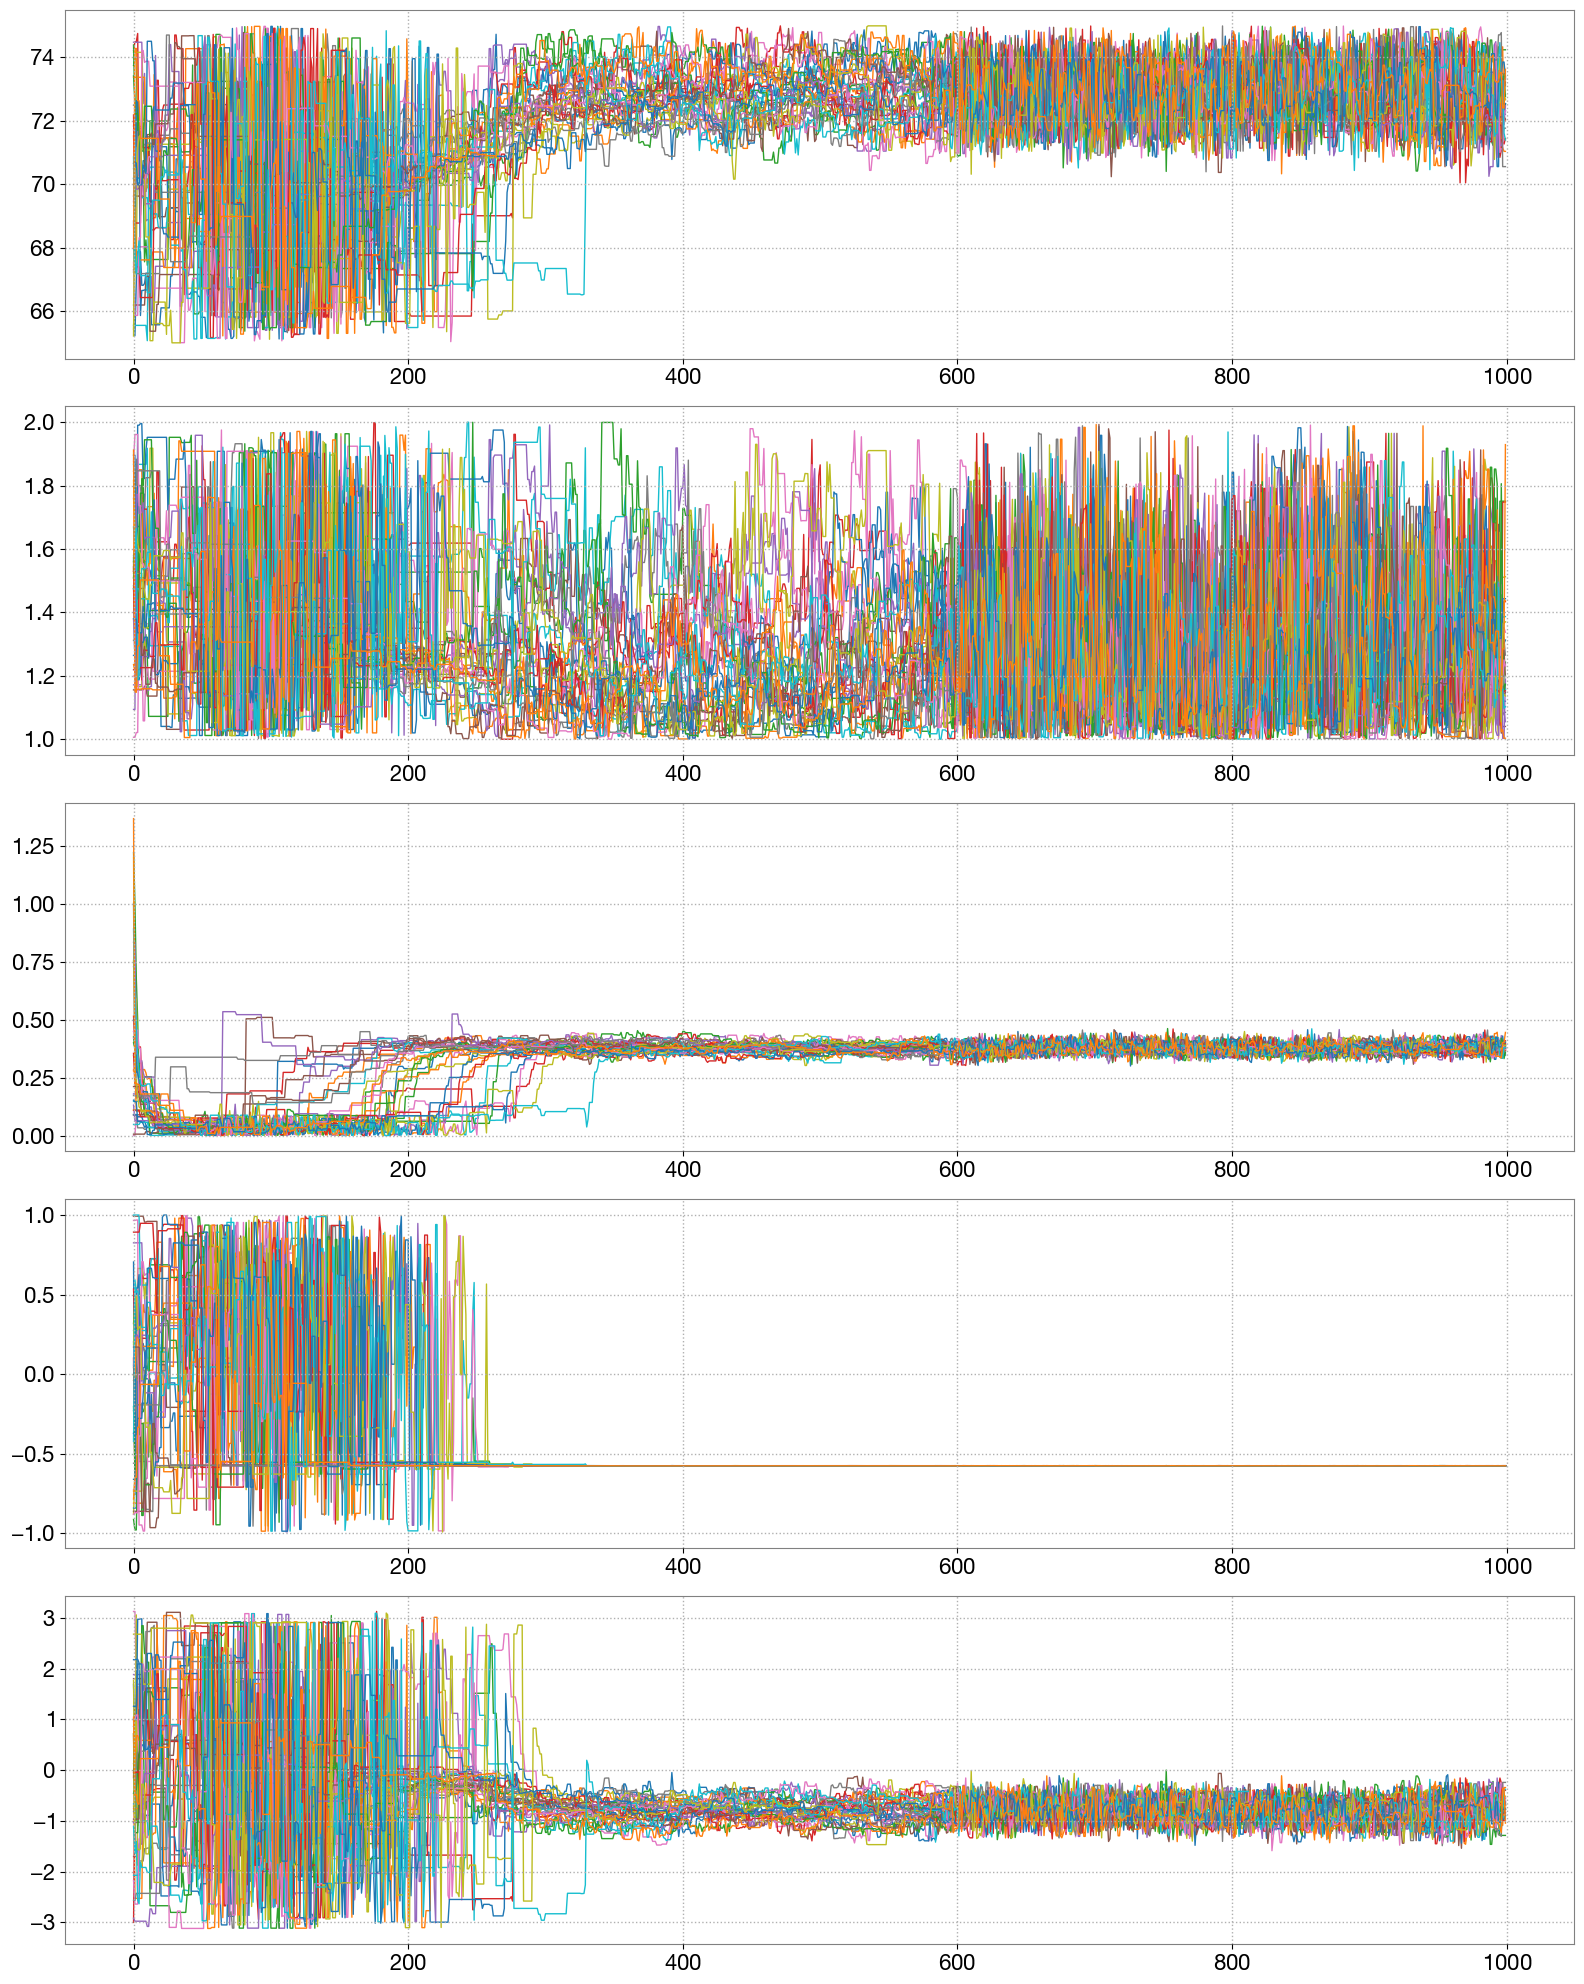

In [173]:
i = 0
pstr = 'M'

fig, axs = plt.subplots(5,1, figsize=[16,20])
for k in range(5):
    for i in range(samples.shape[2]):
        axs[k].plot(np.arange(samples.shape[0]), samples[:,0,i,:,k])

    ax.set_xlabel(r'Steps')
    # ax.set_ylabel(r'$-\ln \mathcal{L} + \mathrm{const.}$')
#     ax.set_title(r'')

fig.tight_layout()

## Run PE - Bilby

In [8]:


class SimpleGaussianLikelihood(bilby.Likelihood):
    def __init__(self, data):
        """
        A very simple Gaussian likelihood

        Parameters
        ----------
        data: array_like
            The data to analyse
        """
        super().__init__(parameters={"mu": None, "sigma": None})
        self.data = data
        self.N = len(data)

    def log_likelihood(self):
        mu = self.parameters["mu"]
        sigma = self.parameters["sigma"]
        res = self.data - mu
        return -0.5 * (
            np.sum((res / sigma) ** 2) + self.N * np.log(2 * np.pi * sigma**2)
        )

data =  bilby.core.utils.random.rng.normal(3, 4, 100)

likelihood = SimpleGaussianLikelihood(data)
priors = dict(
    mu=bilby.core.prior.Uniform(0, 5, "mu"),
    sigma=bilby.core.prior.Uniform(0, 10, "sigma"),
)

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood,
    priors=priors,
    sampler="dynesty",
    nlive=1000,
    outdir='./samples/',
    label='test',
    save=False,
)
result.plot_corner()

12:15 bilby INFO    : Running for label 'test', output will be saved to './samples/'
12:15 bilby INFO    : Analysis priors:
12:15 bilby INFO    : mu=Uniform(minimum=0, maximum=5, name='mu', latex_label='mu', unit=None, boundary=None)
12:15 bilby INFO    : sigma=Uniform(minimum=0, maximum=10, name='sigma', latex_label='sigma', unit=None, boundary=None)
12:15 bilby INFO    : Analysis likelihood class: <class '__main__.SimpleGaussianLikelihood'>
12:15 bilby INFO    : Analysis likelihood noise evidence: nan
12:15 bilby INFO    : Single likelihood evaluation took 7.697e-05 s
12:15 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 1000, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None, 'grad_args': None, 'grad_

ModuleNotFoundError: No module named 'numpy._core'

In [6]:
bilby.run_sampler?

Signature:
bilby.run_sampler(
    likelihood,
    priors=None,
    label='label',
    outdir='outdir',
    sampler='dynesty',
    use_ratio=None,
    injection_parameters=None,
    conversion_function=None,
    plot=False,
    default_priors_file=None,
    clean=None,
    meta_data=None,
    save=True,
    gzip=False,
    result_class=None,
    npool=1,
    **kwargs,
)
Docstring:
The primary interface to easy parameter estimation

Parameters
likelihood: `bilby.Likelihood`
    A `Likelihood` instance
priors: `bilby.PriorDict`
    A PriorDict/dictionary of the priors for each parameter - missing
    parameters will use default priors, if None, all priors will be default
label: str
    Name for the run, used in output files
outdir: str
    A string used in defining output files
sampler: str, Sampler
    The name of the sampler to use - see
    `bilby.sampler.get_implemented_samplers()` for a list of available
    samplers.
    Alternatively a Sampler object can be passed
use_ratio: bool (

## Run PE - ptemcee

In [22]:
# Params: M, q, A, Deltat, alpha
prior_range = np.array([
    [50., 80.],
    [1., 2.],
    [0., 2.],
    [-1., 1.],
    [-np.pi, np.pi]])

In [32]:
ndim = 5
nwalkers = 64
ntemps = 5
Tmax = 100
niter = 1000
burn_in = int(niter/2)

datadir = './samples/'
name = 'gw150914_example'

# Initialization: draw from prior
xini = np.zeros((ntemps,nwalkers,ndim), dtype=float)
# Uniform f0, fdot0, amp, phi0, lambd, psi
for i in range(5):
    xini[:,:,i] = np.random.uniform(low=prior_range[i,0], high=prior_range[i,1], size=(ntemps,nwalkers))

# Temperatures
betas = ptemcee.sampler.make_ladder(ndim, ntemps=ntemps, Tmax=Tmax)

# Sampler
sampler = ptemcee.sampler.Sampler(nwalkers, ndim, lnlike, lnprior, logl_kwargs=[], logp_kwargs={'prior_bounds': prior_range}, betas=betas, adaptive=True, list_param_wrap=[None, None, None, None, [-np.pi, np.pi]])
chain = sampler.chain(xini)

# Initial likelihood values
lnLvals_ini = np.zeros((ntemps,nwalkers), dtype=float)
for i in range(ntemps):
    for j in range(nwalkers):
        lnLvals_ini[i,j] = lnlike(xini[i,j,:])

In [33]:
%time _ = chain.run(niter)

CPU times: user 13min 45s, sys: 2.62 s, total: 13min 48s
Wall time: 13min 48s


In [34]:
chain_unfold = np.transpose(chain.x[:,0,:,:], axes=(1,0,2))
# Same format without ndim for like and post values
lnlikevals = np.transpose(chain.logl[:,0,:], axes=(1,0))
lnpostvals = np.transpose(chain.logP[:,0,:], axes=(1,0))

thin_len = 1
n_fixed = 0
n_out = nwalkers * ((niter-burn_in-1) // thin_len + 1)
chain_processed = np.zeros((n_out, ndim + n_fixed), dtype=float)
for i in range(ndim):
#     i_out = list_params.index(infer_params[i])
    chain_processed[:,i] = np.ravel(chain_unfold[:,burn_in::thin_len,i],
                                        order='F')
lnlike_processed = np.ravel(lnlikevals[:,burn_in::thin_len], order='F')

# Output to file
np.save(datadir + 'chain_unfold_' + name + '.npy', chain_unfold)
np.save(datadir + 'lnlikevals_' + name + '.npy', lnlikevals)
np.save(datadir + 'chain_processed_' + name + '.npy', chain_processed)
np.save(datadir + 'lnlike_processed_' + name + '.npy', lnlike_processed)

In [148]:
# array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
#         -5.70273657e-02]),
#  -30730.802799080564,

lnlike(np.array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
        -5.70273657e-02]))

np.float64(-30731.539182743567)

In [48]:
%timeit lnlike(xini[0,0,:])

2.32 ms ± 65.9 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


### Results

In [35]:
datadir = './samples/'
name = 'gw150914_example'

chain_unfold = np.load(datadir + 'chain_unfold_' + name + '.npy')
lnlikevals = np.load(datadir + 'lnlikevals_' + name + '.npy')
chain_processed = np.load(datadir + 'chain_processed_' + name + '.npy')
lnlike_processed = np.load(datadir + 'lnlike_processed_' + name + '.npy')

In [36]:
chain_unfold.shape

(64, 1000, 5)

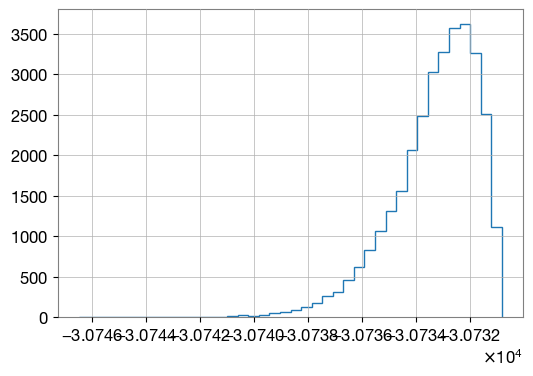

In [38]:
fig, ax = plt.subplots(1,1, figsize=[6,4])
ax.hist(lnlike_processed, histtype='step', bins=40);

Text(0.5, 1.0, '')

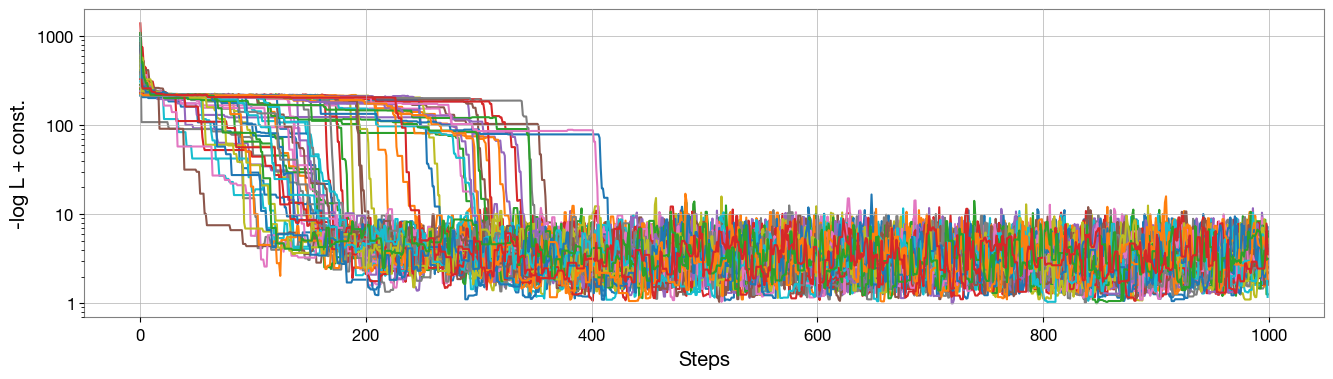

In [41]:
lnL_max = np.max(lnlike_processed)

fig, ax = plt.subplots(1,1, figsize=[16,4])
for i in range(lnlikevals.shape[0]):
    ax.plot(np.arange(lnlikevals.shape[1]), -(lnlikevals[i] - lnL_max - 1))

ax.set_yscale('log')
ax.set_xlabel(r'Steps')
ax.set_ylabel(r'-log L + const.')
ax.set_title(r'')

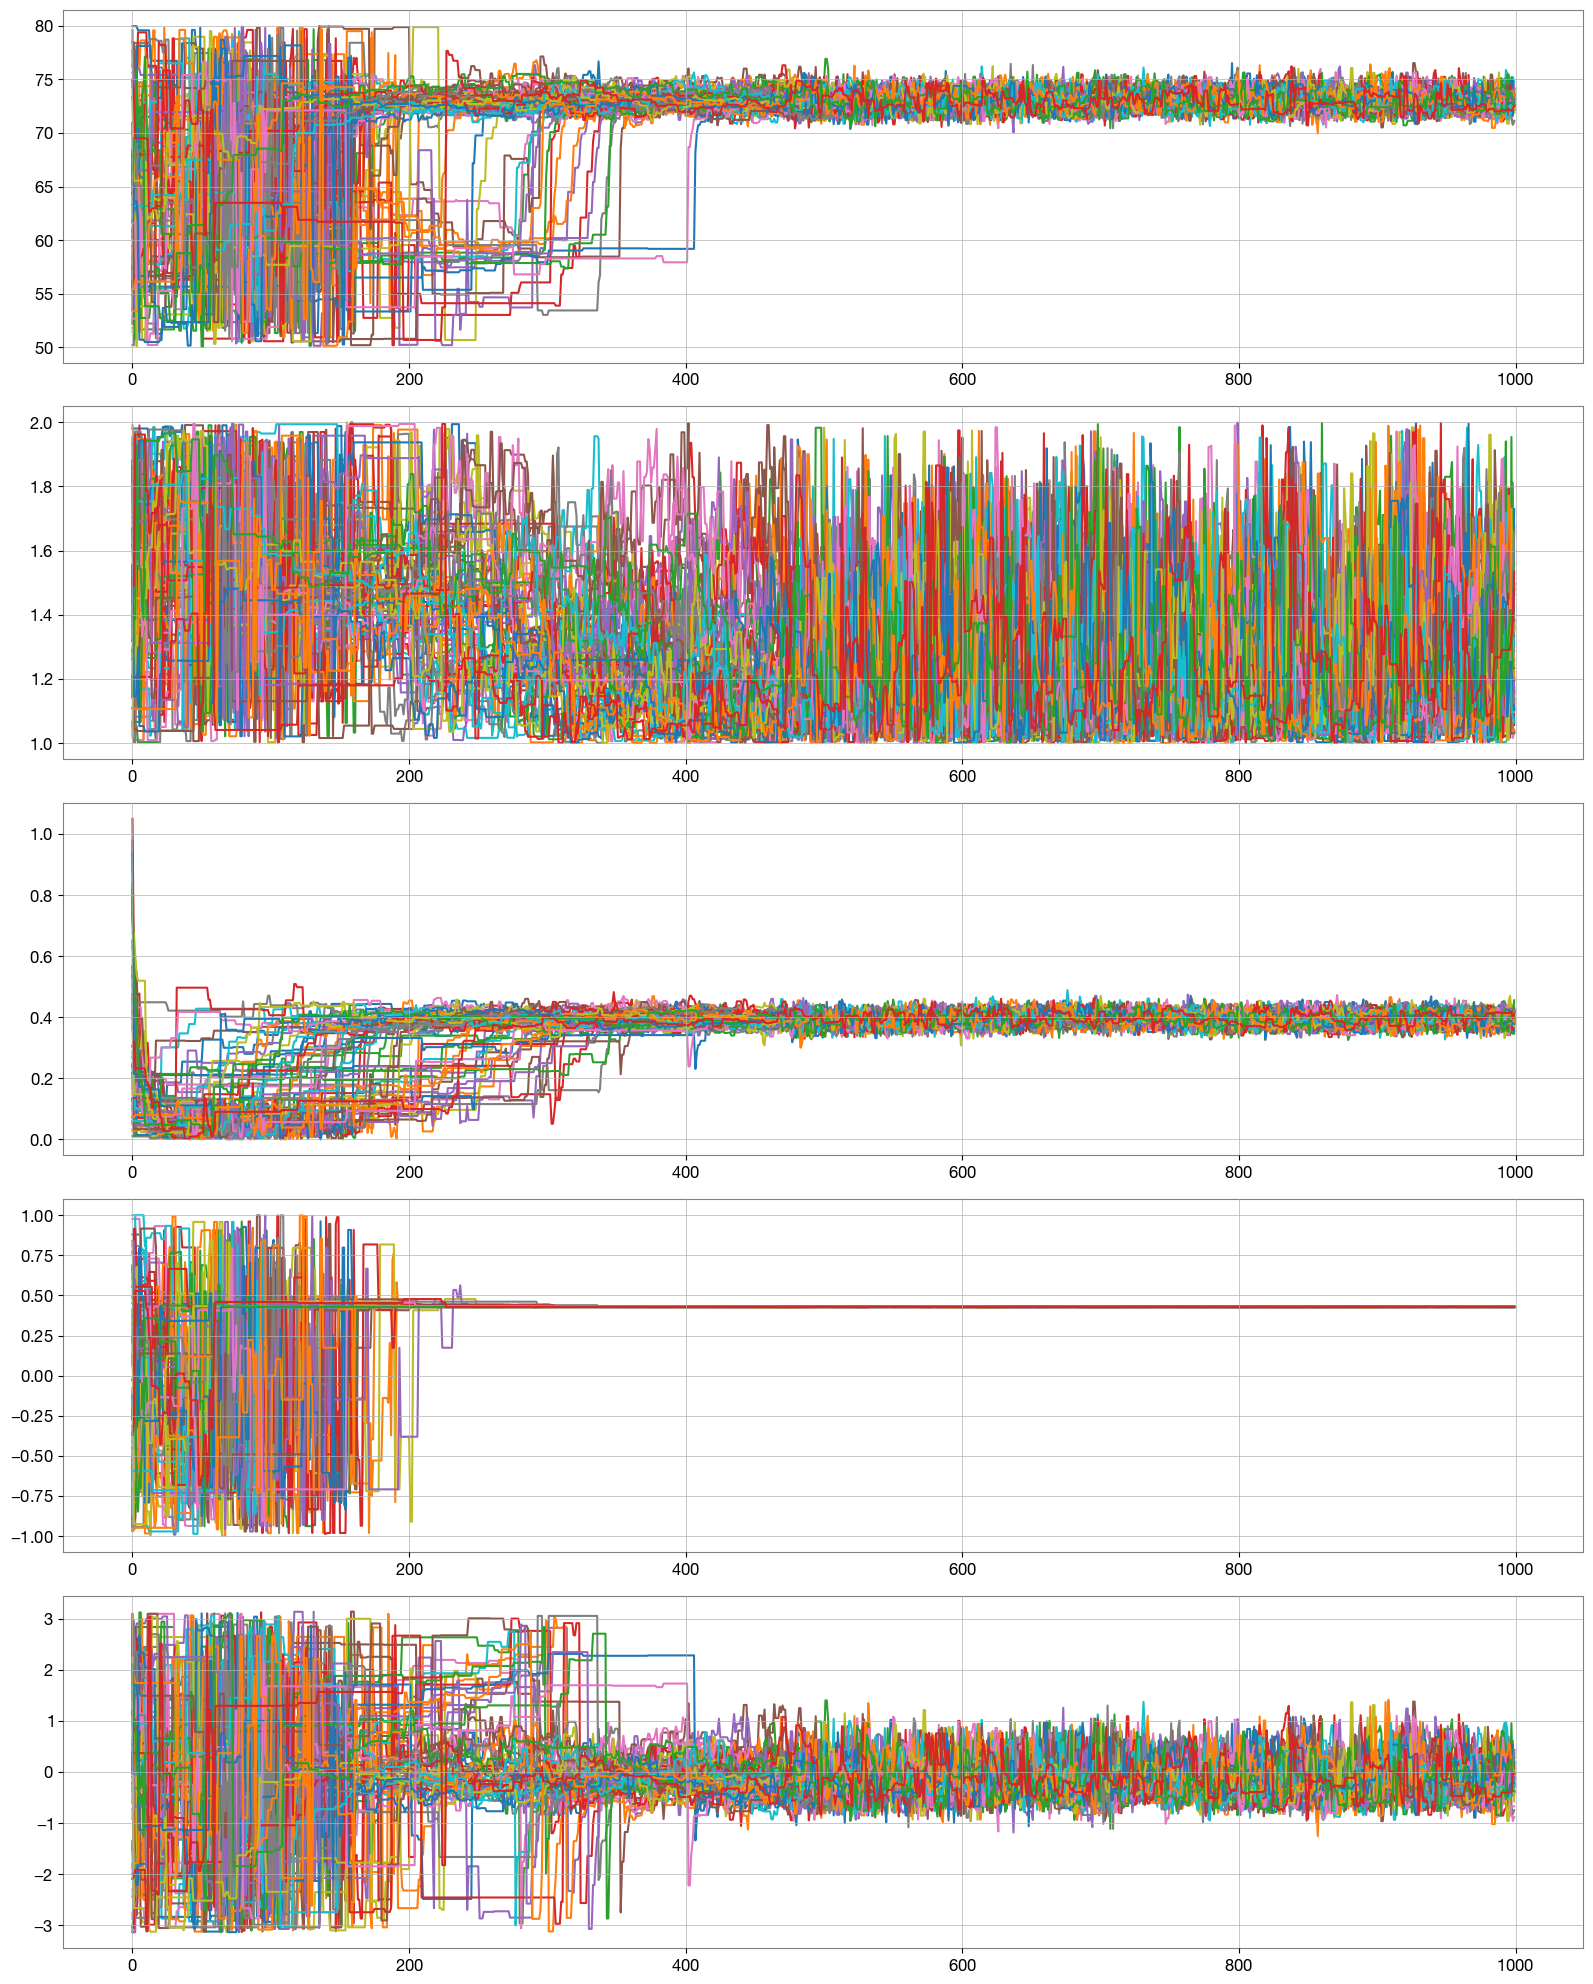

In [43]:
i = 0
pstr = 'M'

fig, axs = plt.subplots(5,1, figsize=[16,20])
for k in range(5):
    for i in range(lnlikevals.shape[0]):
        axs[k].plot(np.arange(lnlikevals.shape[1]), chain_unfold[i,:,k])

    ax.set_xlabel(r'Steps')
    # ax.set_ylabel(r'$-\ln \mathcal{L} + \mathrm{const.}$')
#     ax.set_title(r'')

fig.tight_layout()

In [44]:
lnlike_processed.shape, chain_processed.shape

((32000,), (32000, 5))

In [45]:
lnL_max = np.max(lnlike_processed)

imax = np.argmax(np.max(lnlike_processed))
xmax = chain_processed[imax]
xmax, lnL_max, len(freq)

(array([72.0409236 ,  1.25386116,  0.38852848,  0.42810148,
        -0.40978564]),
 np.float64(-30730.8138006195),
 32447)

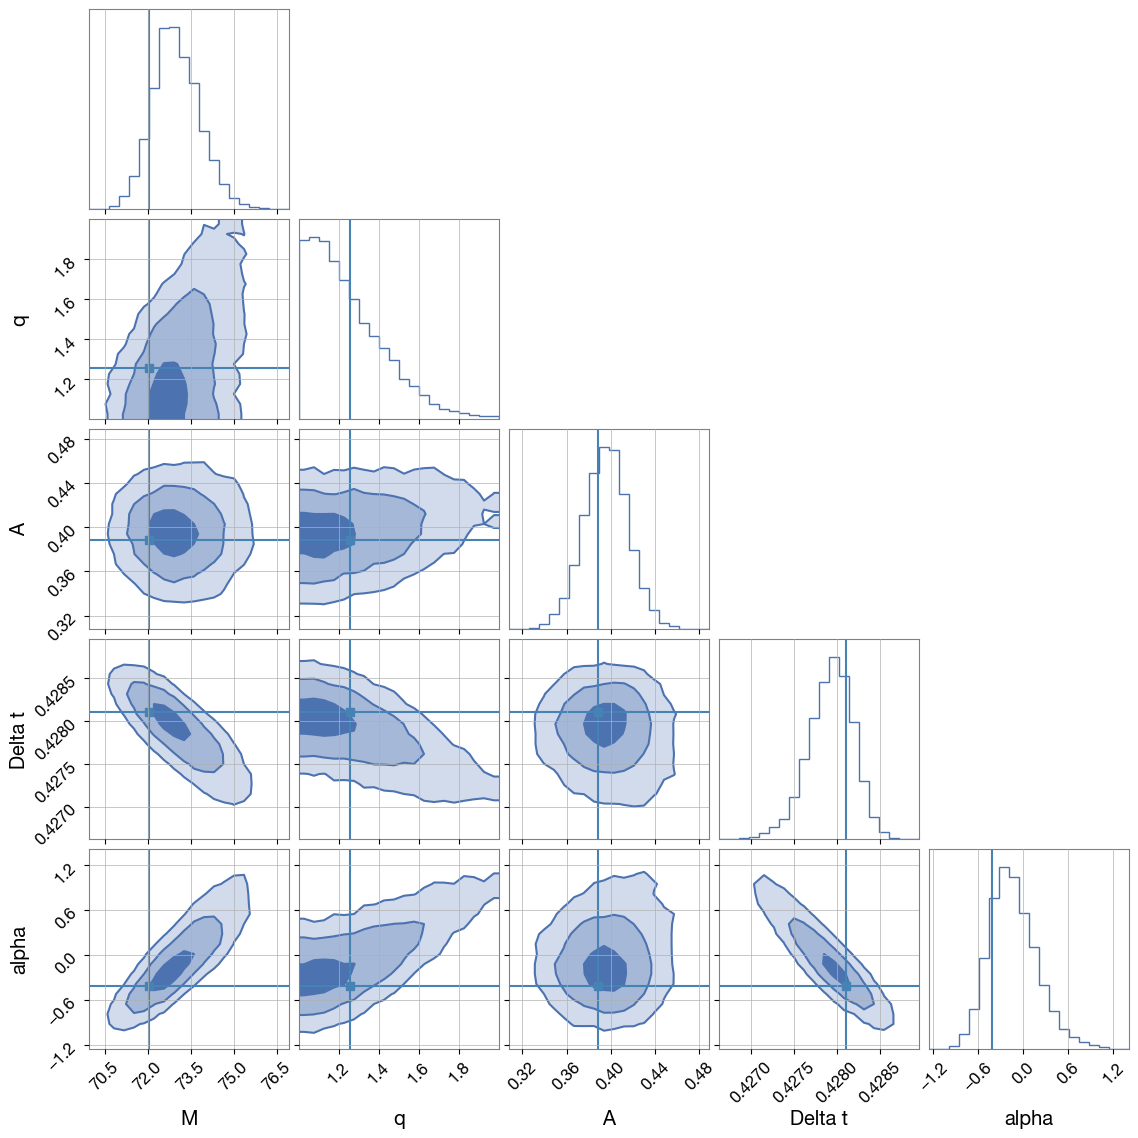

In [46]:
labels = [r'M', r'q', r'A', r'Delta t', r'alpha']
levels = 1.0 - np.exp(-0.5 * np.linspace(1.0, 3.0, num=3) ** 2)

corner.corner(chain_processed, truths=xmax, plot_density=False, plot_datapoints=False, levels=levels, smooth=0.5, color='#4C72B0', fill_contours=True, labels=labels);

## Waveform for max likelihood and residuals

In [34]:
# Data whitened after band-passing

f_d = freq_H1
w_bp = window_planck(f_d, 10., 512., 10., 64.)

strain_H1_fd_wbp = w_bp * np.sqrt(2*df / psd_H1_interp(f_d)) * strain_H1_fd
strain_L1_fd_wbp = w_bp * np.sqrt(2*df / psd_L1_interp(f_d)) * strain_L1_fd

_, strain_H1_td_wbp = ifft_positivef(f_d, strain_H1_fd_wbp, real=True, tstart=times_d[0])
_, strain_L1_td_wbp = ifft_positivef(f_d, strain_L1_fd_wbp, real=True, tstart=times_d[0])

NameError: name 'freq_H1' is not defined

In [241]:
Mmax, qmax, Amax, Deltatmax, alphamax = xmax
xmax

array([72.67701483,  1.02898998,  0.37424392, -0.57658854,
       -0.76416395])

In [237]:
fmax, hmax = signal_h(freq, M0, q0, A0, Deltat0, alpha0)

In [246]:
mask_h = (freq[0] <= f_d) & (f_d <= freq[-1])

def htemplate_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    return ifft_positivef(f_d, h_fd, real=True, tstart=times_d[0])
    
def htemplate_wbp_td(M, q, A, Deltat, alpha):
    f, h = signal_h(freq, M, q, A, Deltat, alpha)
    w_ifft = window_planck(f_d, freq[0], freq[-1], 5., 128.)
    h_fd = np.zeros_like(f_d, dtype=complex)
    h_fd[mask_h] = w_ifft[mask_h] * h
    h_wbp_fd =  np.sqrt((2 * df) / psd_H1_interp(f_d)) * h_fd 
    return ifft_positivef(f_d, h_wbp_fd, real=True, tstart=times_d[0])

In [247]:
tmax, hmax_td = htemplate_td(Mmax, qmax, Amax, Deltatmax, alphamax)
tmax, hmax_wbp = htemplate_wbp_td(Mmax, qmax, Amax, Deltatmax, alphamax)

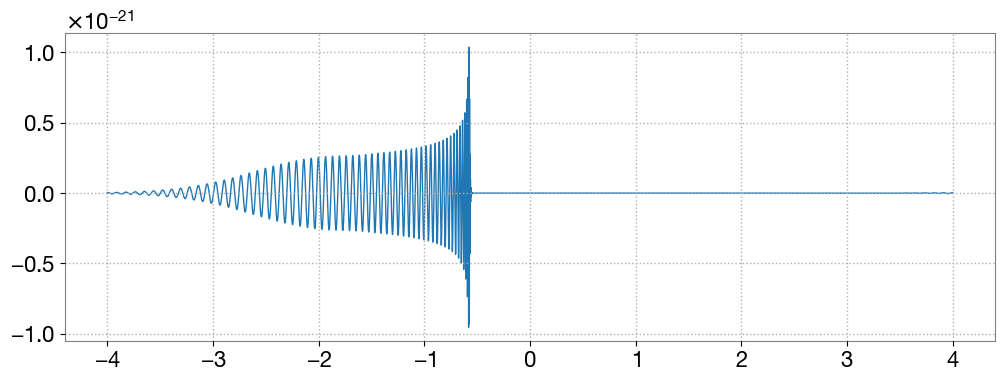

In [248]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(tmax, hmax_td)

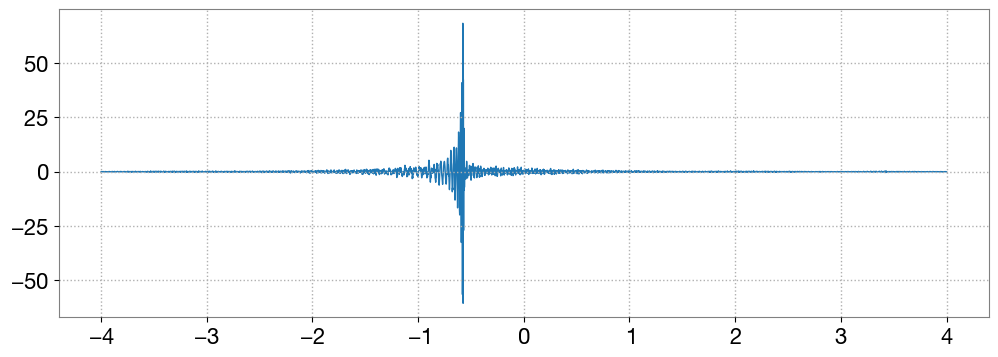

In [245]:
fig, ax = plt.subplots(1,1, figsize=[12,4])
ax.plot(tmax, hmax_wbp)

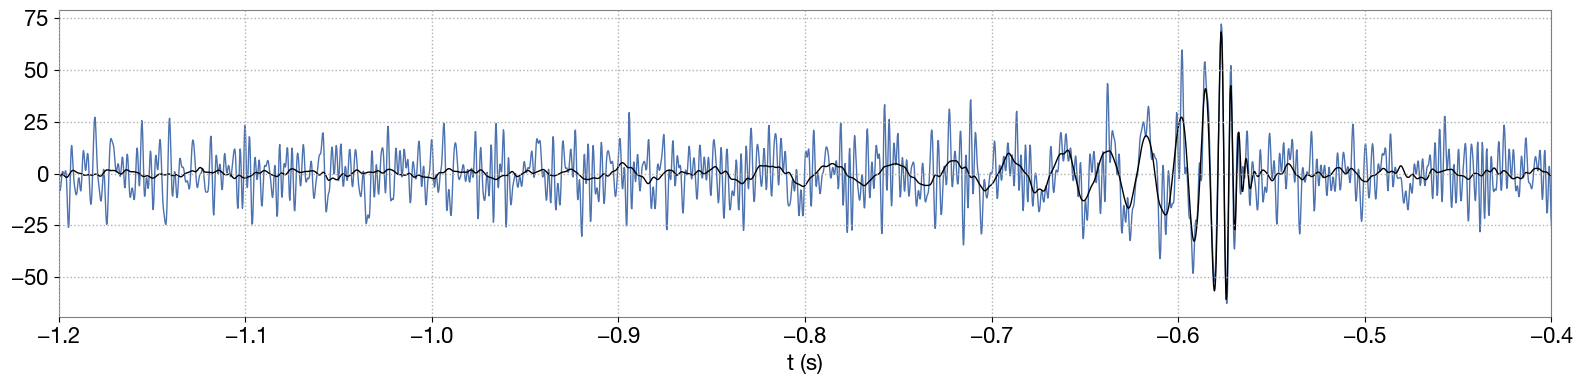

In [253]:
fig, ax = plt.subplots(1,1, figsize=[16,4])
ax.plot(times_d, strain_H1_td_wbp, c=colors[0])
ax.plot(times_d, hmax_wbp, c='k')

ax.set_xlim([-1.2, -0.4])
ax.set_xlabel(r't (s)')

fig.tight_layout()

In [255]:
n_rand = 1000
inds = np.random.choice(range(len(samples_flat)), size=n_rand, replace=False)

h_wbp_td_all = np.zeros((len(times_d), n_rand), dtype=float)
for i in tqdm(range(n_rand)):
    M, q, A, Deltat, alpha = samples_flat[inds[i]]
    _, h_wbp_td_vals = htemplate_wbp_td(M, q, A, Deltat, alpha)
    h_wbp_td_all[:,i] = h_wbp_td_vals

  0%|          | 0/1000 [00:00<?, ?it/s]

In [256]:
qs = np.array([0.025, 0.16, 0.5, 0.84, 0.975])

h_wbp_td_quantiles = np.quantile(h_wbp_td_all, qs, axis=1)
h_wbp_td_quantiles.shape

(5, 32768)

(-1.2, -0.4)

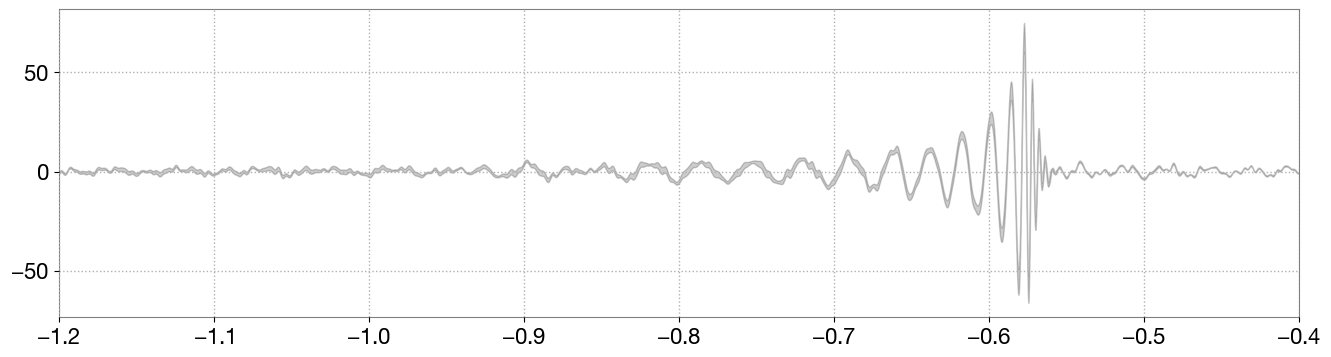

In [261]:
# NOTE: 2sigma waveform reconstruction is very narrow

trange = [-1.2, -0.4]

fig, ax = plt.subplots(1,1, figsize=[16,4])
# ax.plot(times_d, strain_H1_td_wbp, c=colors[0])
# ax.plot(times_d, hmax_wbp, c='k')
ax.fill_between(times_d, h_wbp_td_quantiles[0], h_wbp_td_quantiles[4], color=['k'], alpha=0.2)

ax.set_xlim(trange)

# Video

In [ ]:
# Final command:

# ffmpeg -framerate 4 -i pe_signal_frame_%04d.png -pix_fmt yuv420p -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" video_pe_signal.mp4

# ffmpeg -framerate 4 -i pe_trace_frame_%04d.png -pix_fmt yuv420p -vf "pad=ceil(iw/2)*2:ceil(ih/2)*2" video_pe_trace.mp4

In [110]:
from matplotlib import gridspec

In [62]:
datadir = './samples/'
name = 'gw150914_example'

chain_unfold = np.load(datadir + 'chain_unfold_' + name + '.npy')
lnlikevals = np.load(datadir + 'lnlikevals_' + name + '.npy')
chain_processed = np.load(datadir + 'chain_processed_' + name + '.npy')
lnlike_processed = np.load(datadir + 'lnlike_processed_' + name + '.npy')

In [97]:
def h_wbp_td(M, q, A, Deltat, alpha):
    h_ext = signal_h(freq_ext, M, q, A, Deltat, alpha)
    h_fd = np.zeros_like(freq_fft, dtype=complex)
    w_ifft = pytools.window_planck_vec(freq_ext, 5., 1024., 5., 128.)
    h_fd[mask_ext] = w_ifft * h_ext['amp'] * np.exp(1j*h_ext['phase'])
    h_wbp_fd =  1./np.sqrt(psd_H1(freq_fft) / (2*df)) * h_fd 
    return pytools.ifft_real(np.array([freq_fft, np.real(h_wbp_fd), np.imag(h_wbp_fd)]).T)

In [ ]:
# Framerate 4, 400 iter, ds=4, 25s

In [288]:
def plt_pe_signal(istep, iframe, iwalkers_in, out=False):
    iwalkers = copy.deepcopy(iwalkers_in) # is it required ?
    h_wbp_td_list = []
    for iwalker in iwalkers:
        M, q, A, Deltat, alpha = chain_unfold[iwalker,istep,:]
        h_wbp_td_list += [h_wbp_td(M, q, A, Deltat, alpha)]
    
    rangex = [-0.8, 0.8]
    rangey = [-40., 40.]
    
    fig, ax = plt.subplots(1,1, figsize=[8,4])
    plotutils.lplot(ax, [time_d, strain_H1_td_wbp[:,1]], rangex=rangex, colors=['lightgrey'], rangey=rangey)
    plotutils.lplot(ax, *[[h_wbp_td_list[i][:,0], h_wbp_td_list[i][:,1]] for i in range(len(iwalkers))], rangex=rangex, rangey=rangey)

    ax.set_xlabel(r'$t \; (\mathrm{s})$')
    
    fig.tight_layout()
    
    if out:
        fig.savefig('./videos/pe_signal_frame_%04d.png' % iframe, dpi=200)

        plt.close(fig)

In [289]:
step_max = 600

def plt_pe_trace(istep, iframe, iwalkers_in, out=False):
    iwalkers = copy.deepcopy(iwalkers_in) # is it required ?
    
    rangex = [0, step_max]
    
    fig, axs = plt.subplots(4,1, figsize=[8,8])
    # lnL
    lnL_max = np.max(lnlike_processed)
    plotutils.llogplot(axs[0], *[[np.arange(step_max), -(lnlikevals[i] - lnL_max - 1)[:step_max]] for i in range(lnlikevals.shape[0])], rangey=None, colors=['lightgrey']*lnlikevals.shape[0])
    plotutils.llogplot(axs[0], *[[np.arange(istep+1), -(lnlikevals[i] - lnL_max - 1)[:istep+1]] for i in iwalkers], rangey=[0.5, 1e3], rangex=rangex)
    axs[0].set_ylabel(r'$-\ln \mathcal{L} + \mathrm{const.}$')
    # M
    plotutils.lplot(axs[1], *[[np.arange(step_max), chain_unfold[i,:step_max,0]] for i in range(lnlikevals.shape[0])], rangey=None, colors=['lightgrey']*lnlikevals.shape[0])
    plotutils.lplot(axs[1], *[[np.arange(istep+1), chain_unfold[i,:istep+1,0]] for i in iwalkers], rangey=[50., 90.], rangex=rangex)
    axs[1].set_ylabel(r'$M \; (M_\odot)$')
    # A
    plotutils.lplot(axs[2], *[[np.arange(step_max), chain_unfold[i,:step_max,2]] for i in range(lnlikevals.shape[0])], rangey=None, colors=['lightgrey']*lnlikevals.shape[0])
    plotutils.lplot(axs[2], *[[np.arange(istep+1), chain_unfold[i,:istep+1,2]] for i in iwalkers], rangey=[0., 1.], rangex=rangex)
    axs[2].set_ylabel(r'$A$')
    # Deltat
    plotutils.lplot(axs[3], *[[np.arange(step_max), chain_unfold[i,:step_max,3]] for i in range(lnlikevals.shape[0])], rangey=None, colors=['lightgrey']*lnlikevals.shape[0])
    plotutils.lplot(axs[3], *[[np.arange(istep+1), chain_unfold[i,:istep+1,3]] for i in iwalkers], rangey=[-1., 1.], rangex=rangex)
    axs[3].set_ylabel(r'$\Delta t \; (s)$')
    
    for i in range(4):
        axs[i].axvline(istep, c='k', ls='--', lw=1.)
    axs[3].set_xlabel(r'$\mathrm{Steps}$')
    
    fig.tight_layout()
    
    if out:
        fig.savefig('./videos/pe_trace_frame_%04d.png' % iframe, dpi=200)

        plt.close(fig)

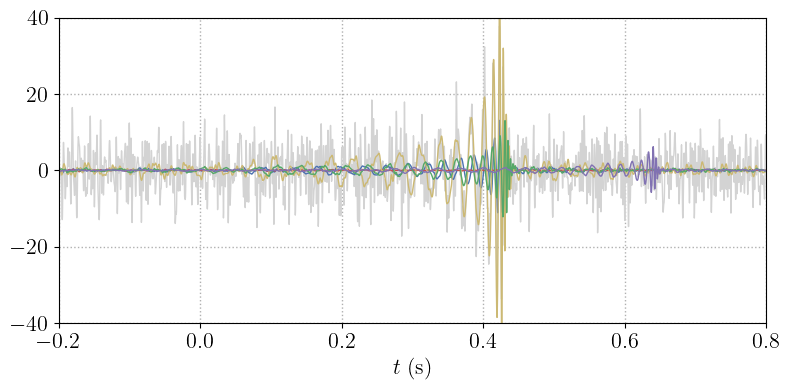

<Figure size 800x400 with 0 Axes>

In [275]:
plt_pe_signal(50, 0, [0,1,2,3,4])

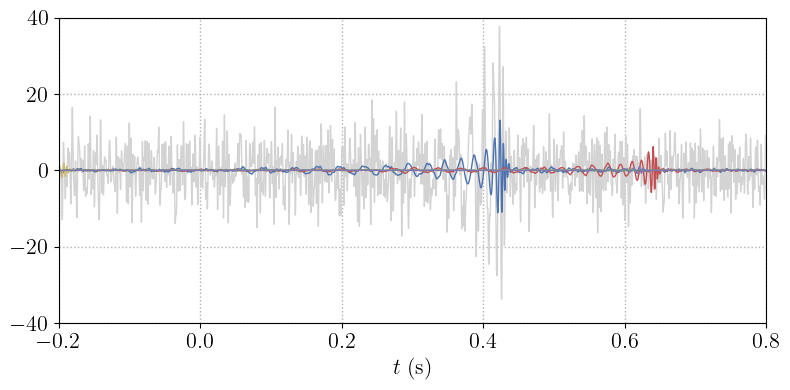

<Figure size 800x400 with 0 Axes>

In [276]:
plt_pe_signal(50, 0, iwalkers)

In [293]:
iwalkers = [0, 4, 8, 12, 16]

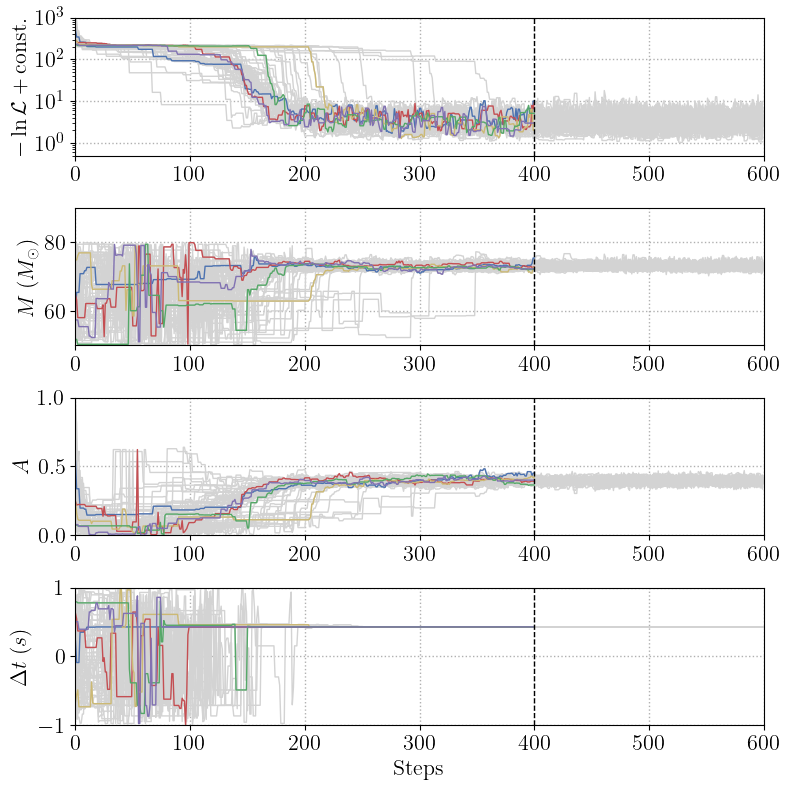

<Figure size 800x400 with 0 Axes>

In [277]:
plt_pe_trace(400, 0, iwalkers)

In [295]:
niter_vid = 400
ds = 1

inds = np.arange(2, niter_vid)
inds_ds = inds[::ds]

for iframe in tqdm(range(len(inds_ds))):
    istep = inds_ds[iframe]
    plt_pe_signal(istep, iframe, iwalkers, out=True)
    plt_pe_trace(istep, iframe, iwalkers, out=True)

  0%|          | 0/398 [00:00<?, ?it/s]

<Figure size 800x400 with 0 Axes>

# Debug

In [123]:
signal_lnLmax = {}
signal_lnLmax['amp'] = np.load('../../gwda/gwda/test/test_h_lnLmax_amp.npy')
signal_lnLmax['phase'] = np.load('../../gwda/gwda/test/test_h_lnLmax_phase.npy')

In [134]:
M, q, A, Deltat, alpha = np.array([ 7.32045084e+01,  1.32900290e+00,  3.94760472e-01,  4.27858963e-01,
        -5.70273657e-02])
signal_lnLmax_new = signal_h(freq, M, q, A, Deltat, alpha)

In [130]:
m1 = M * q / (1+q)
m2 = M * 1. / (1+q)
dist = 1e3
chi1 = 0.
chi2 = 0.
wfClass = pyIMRPhenomD.IMRPhenomDh22AmpPhase(freq, m1, m2, chi1, chi2, dist)
hlm = wfClass.get_waveform()
h = hlm[(2,2)]
h['phase']

array([148.32365525, 147.49805261, 146.67953592, ...,
         0.        ,   0.        ,   0.        ], shape=(32447,))

In [132]:
h['phase'].shape

(32447,)

In [131]:
freq

array([  10.03125,   10.0625 ,   10.09375, ..., 1023.90625,
       1023.9375 , 1023.96875], shape=(32447,))

In [125]:
signal_lnLmax_new['amp'] / signal_lnLmax['amp']

array([1., 1., 1., ..., 0., 0., 0.], shape=(32447,))

In [135]:
signal_lnLmax_new['phase'] + signal_lnLmax['phase']

array([0.        , 0.        , 0.        , ..., 1.55104607,
       1.5512192 , 1.55139234], shape=(32447,))